# 실습 04 · UCI HAR: 1D CNN과 LSTM 공정 비교

**목표**

- 실제 HAR 관성 센서를 `(N,9,128)`로 읽는다.
- 같은 split·전처리·학습 조건으로 Conv1d와 LSTM을 학습한다.
- Conv1d의 지역 패턴과 LSTM의 누적 상태 관점을 비교한다.
- LSTM hidden size 변경의 용량·시간 trade-off를 예상한다.

## 1. 환경·로컬 HAR 데이터

In [1]:
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


In [2]:
from pathlib import Path

def find_project_root(start=None):
    """노트북 위치가 달라도 프로젝트의 로컬 데이터를 찾습니다."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("data 폴더를 찾지 못했습니다. 노트북과 같은 위치(또는 상위)에 data 폴더가 있어야 합니다.")

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
print("project:", PROJECT_ROOT.name)
print("data exists:", DATA_ROOT.exists())


project: edu_0814
data exists: True


In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HAR_ROOT = DATA_ROOT / "UCI HAR Dataset"
assert HAR_ROOT.exists(), HAR_ROOT
print("device:", DEVICE, "HAR:", HAR_ROOT.name)


device: cpu HAR: UCI HAR Dataset


## 2. 9개 inertial signal 읽기

In [4]:
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]
CLASS_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

def load_har_split(split):
    signal_dir = HAR_ROOT / split / "Inertial Signals"
    channels = [np.loadtxt(signal_dir / f"{name}_{split}.txt", dtype=np.float32) for name in SIGNAL_NAMES]
    X = np.stack(channels, axis=1)  # (N,9,128)
    y = np.loadtxt(HAR_ROOT / split / f"y_{split}.txt", dtype=np.int64) - 1
    return X, y

X_official_train, y_official_train = load_har_split("train")
X_official_test, y_official_test = load_har_split("test")
print("official train:", X_official_train.shape, y_official_train.shape)
print("official test :", X_official_test.shape, y_official_test.shape)


official train: (7352, 9, 128) (7352,)
official test : (2947, 9, 128) (2947,)


## 활동별 sample 수

class 분포를 확인하면 accuracy를 해석할 때 특정 활동이 과도하게 많은지 알 수 있습니다.

,activity,train,test
0,WALKING,1226,496
1,WALKING_UPSTAIRS,1073,471
2,WALKING_DOWNSTAIRS,986,420
3,SITTING,1286,491
4,STANDING,1374,532
5,LAYING,1407,537


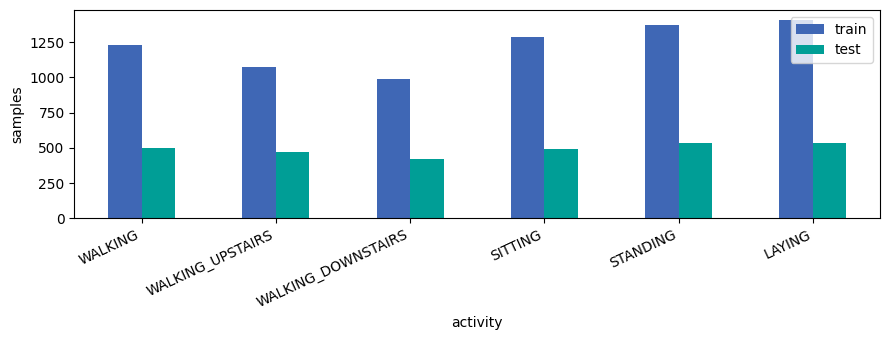

In [5]:
train_counts = np.bincount(y_official_train, minlength=6)
test_counts = np.bincount(y_official_test, minlength=6)
count_table = pd.DataFrame({"activity": CLASS_NAMES, "train": train_counts, "test": test_counts})
display(count_table)
count_table.set_index("activity").plot.bar(figsize=(9, 3.5), color=["#3F67B5", "#009E96"])
plt.ylabel("samples"); plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()


한 sample은 9개 센서 채널이 128시점 동안 기록된 window입니다. 공식 test split은 마지막 확인에만 사용합니다.

## 3. 한 window 시각화

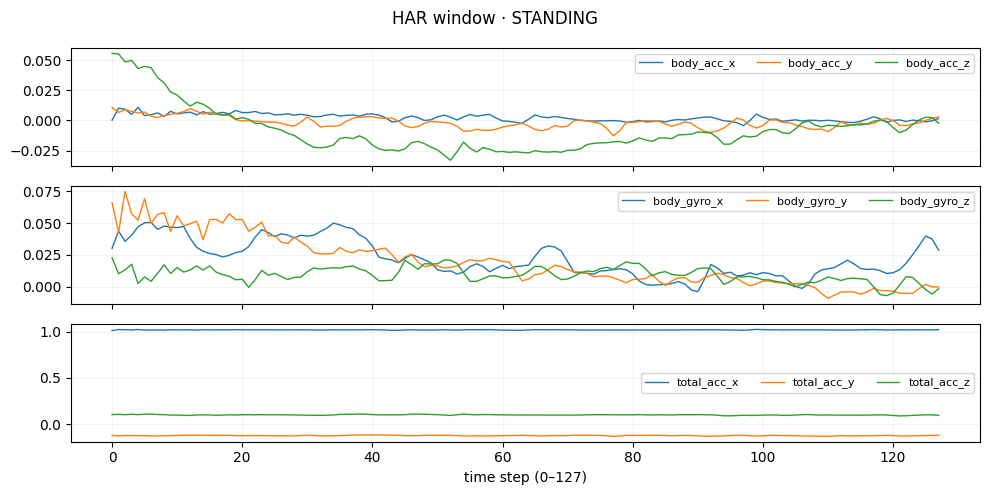

In [6]:
sample_id = 0
fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
for group, ax in enumerate(axes):
    for axis in range(3):
        channel = group * 3 + axis
        ax.plot(X_official_train[sample_id, channel], label=SIGNAL_NAMES[channel], linewidth=1)
    ax.legend(ncol=3, fontsize=8); ax.grid(alpha=.15)
axes[-1].set_xlabel("time step (0–127)")
fig.suptitle(f"HAR window · {CLASS_NAMES[y_official_train[sample_id]]}")
plt.tight_layout(); plt.show()


## window의 요약 통계

채널마다 값의 범위가 다르면 큰 범위의 채널이 gradient에 더 큰 영향을 줄 수 있습니다.

In [7]:
signal_summary = pd.DataFrame({
    "channel": SIGNAL_NAMES,
    "mean": X_official_train.mean(axis=(0, 2)),
    "std": X_official_train.std(axis=(0, 2)),
    "min": X_official_train.min(axis=(0, 2)),
    "max": X_official_train.max(axis=(0, 2)),
})
display(signal_summary.round(3))


,channel,mean,std,min,max
0,body_acc_x,-0.001,0.195,-1.232,1.300
1,body_acc_y,-0.000,0.122,-1.345,0.976
2,body_acc_z,-0.000,0.107,-1.365,1.067
3,body_gyro_x,0.001,0.407,-4.734,4.155
4,body_gyro_y,-0.001,0.382,-5.974,5.746
5,body_gyro_z,0.000,0.256,-2.763,2.366
6,total_acc_x,0.805,0.414,-0.467,2.198
7,total_acc_y,0.029,0.391,-1.582,1.217
8,total_acc_z,0.086,0.358,-1.640,1.281


## 4. 동일 split과 CPU용 수업용 subset

In [8]:
all_idx = np.arange(len(y_official_train))
train_idx, val_idx = train_test_split(
    all_idx, test_size=.20, stratify=y_official_train, random_state=SEED
)

def stratified_limit(indices, labels, limit, seed):
    if len(indices) <= limit:
        return indices
    chosen, _ = train_test_split(indices, train_size=limit, stratify=labels[indices], random_state=seed)
    return np.sort(chosen)

train_idx = stratified_limit(train_idx, y_official_train, 1800, SEED)
val_idx = stratified_limit(val_idx, y_official_train, 450, SEED)
test_idx = stratified_limit(np.arange(len(y_official_test)), y_official_test, 900, SEED)

X_train, y_train = X_official_train[train_idx], y_official_train[train_idx]
X_val, y_val = X_official_train[val_idx], y_official_train[val_idx]
X_test, y_test = X_official_test[test_idx], y_official_test[test_idx]
print("classroom train/val/test:", X_train.shape, X_val.shape, X_test.shape)
print("train class count:", np.bincount(y_train))


classroom train/val/test: (1800, 9, 128) (450, 9, 128) (900, 9, 128)
train class count: [300 263 242 315 336 344]


CPU 수업시간을 위해 공식 split 안에서 stratified subset을 고정합니다. 두 모델은 **완전히 같은 index**를 사용합니다.

## 5. train 통계량으로 채널별 표준화

In [9]:
channel_mean = X_train.mean(axis=(0, 2), keepdims=True)
channel_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
X_train = ((X_train - channel_mean) / channel_std).astype(np.float32)
X_val = ((X_val - channel_mean) / channel_std).astype(np.float32)
X_test = ((X_test - channel_mean) / channel_std).astype(np.float32)
print("train channel mean:", np.round(X_train.mean(axis=(0, 2)), 3))
print("tensor contract: Conv1d", X_train.shape, "LSTM", (len(X_train), 128, 9))


train channel mean: [-0. -0. -0.  0.  0. -0. -0.  0.  0.]
tensor contract: Conv1d (1800, 9, 128) LSTM (1800, 128, 9)


**Shape checkpoint:** 저장 tensor는 공통으로 `(N,9,128)`을 사용합니다. LSTM 모델 내부에서만 `(N,128,9)`로 transpose합니다.

## 6. 두 모델이 공유하는 DataLoader

In [10]:
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

def make_loaders(seed):
    generator = torch.Generator().manual_seed(seed)
    return (
        DataLoader(train_dataset, batch_size=128, shuffle=True, generator=generator, num_workers=0),
        DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0),
        DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0),
    )

preview_loader, _, _ = make_loaders(SEED)
xb, yb = next(iter(preview_loader))
print("shared input:", xb.shape, "labels:", yb.shape)


shared input: torch.Size([128, 9, 128]) labels: torch.Size([128])


## 7. 1D CNN: 지역 시간 패턴

In [11]:
class HARConv1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(9, 16, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(32, 6)
    def forward(self, x):
        return self.classifier(self.features(x).squeeze(-1))

cnn = HARConv1D().to(DEVICE)
with torch.no_grad(): print("CNN:", xb.shape, "→", cnn(xb.to(DEVICE)).shape)
print("CNN parameters:", sum(p.numel() for p in cnn.parameters()))


CNN: torch.Size([128, 9, 128]) → torch.Size([128, 6])
CNN parameters: 3526


## Conv1d block별 shape 추적

kernel은 시간축을 따라 이동하고 pooling은 sequence 길이를 줄입니다.

In [12]:
z = xb[:4].to(DEVICE)
print("input", tuple(z.shape))
with torch.no_grad():
    for layer in cnn.features:
        z = layer(z)
        print(f"{layer.__class__.__name__:>18} → {tuple(z.shape)}")
    print("logits →", tuple(cnn.classifier(z.squeeze(-1)).shape))


input (4, 9, 128)
            Conv1d → (4, 16, 128)
              ReLU → (4, 16, 128)
         MaxPool1d → (4, 16, 64)
            Conv1d → (4, 32, 64)
              ReLU → (4, 32, 64)
 AdaptiveAvgPool1d → (4, 32, 1)
logits → (4, 6)


Conv1d kernel은 128시점 전체가 아니라 짧은 구간을 훑으며 반복되는 지역 패턴을 찾습니다.

## 8. LSTM: 순서와 누적 상태

In [13]:
LSTM_HIDDEN = 24  # 학습자 변경 변수

class HARLSTM(nn.Module):
    def __init__(self, hidden_size=LSTM_HIDDEN):
        super().__init__()
        self.lstm = nn.LSTM(input_size=9, hidden_size=hidden_size, batch_first=True)
        self.classifier = nn.Linear(hidden_size, 6)
    def forward(self, x):
        sequence = x.transpose(1, 2)  # (N,9,128) → (N,128,9)
        _, (hidden, _) = self.lstm(sequence)
        return self.classifier(hidden[-1])

lstm = HARLSTM().to(DEVICE)
with torch.no_grad(): print("LSTM:", xb.shape, "→ transpose →", (len(xb), 128, 9), "→", lstm(xb.to(DEVICE)).shape)
print("LSTM parameters:", sum(p.numel() for p in lstm.parameters()))


LSTM: torch.Size([128, 9, 128]) → transpose → (128, 128, 9) → torch.Size([128, 6])
LSTM parameters: 3510


## LSTM 내부 출력 shape

LSTM은 모든 시점의 hidden output과 마지막 hidden/cell state를 함께 반환합니다.

In [14]:
sequence = xb[:4].transpose(1, 2).to(DEVICE)
with torch.no_grad():
    sequence_output, (hidden_state, cell_state) = lstm.lstm(sequence)
print("sequence input:", sequence.shape)
print("all hidden outputs:", sequence_output.shape)
print("last hidden state:", hidden_state.shape)
print("last cell state:", cell_state.shape)


sequence input: torch.Size([4, 128, 9])
all hidden outputs: torch.Size([4, 128, 24])
last hidden state: torch.Size([1, 4, 24])
last cell state: torch.Size([1, 4, 24])


LSTM은 매 시점의 입력과 이전 상태를 결합합니다. 마지막 hidden state를 128시점의 요약으로 사용합니다.

## 9. 공통 학습·검증 함수

In [15]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = total_correct = total_count = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if training: optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits = model(xb); loss = criterion(logits, yb)
            if training: loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_count += len(yb)
    return total_loss / total_count, total_correct / total_count

def train_model(model, seed, epochs=3):
    train_loader, val_loader, test_loader = make_loaders(seed)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=.001)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "seconds": []}
    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        elapsed = time.perf_counter() - started
        for key, value in zip(list(history)[:4], [tr_loss, va_loss, tr_acc, va_acc]): history[key].append(value)
        history["seconds"].append(elapsed)
        print(f"{epoch} | train {tr_loss:.3f}/{tr_acc:.3f} | val {va_loss:.3f}/{va_acc:.3f} | {elapsed:.1f}s")
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    return history, test_loss, test_acc


## 10. 같은 조건으로 1D CNN 학습

In [16]:
torch.manual_seed(SEED)
cnn = HARConv1D().to(DEVICE)
cnn_history, cnn_test_loss, cnn_test_acc = train_model(cnn, SEED, epochs=10)


1 | train 1.752/0.171 | val 1.656/0.327 | 0.2s


2 | train 1.573/0.359 | val 1.431/0.362 | 0.2s
3 | train 1.348/0.382 | val 1.228/0.449 | 0.2s


4 | train 1.197/0.487 | val 1.124/0.507 | 0.2s
5 | train 1.094/0.565 | val 1.021/0.691 | 0.2s


6 | train 0.989/0.721 | val 0.911/0.727 | 0.2s
7 | train 0.870/0.766 | val 0.782/0.816 | 0.2s


8 | train 0.738/0.818 | val 0.651/0.849 | 0.2s
9 | train 0.613/0.857 | val 0.545/0.836 | 0.2s


10 | train 0.525/0.857 | val 0.470/0.853 | 0.2s


## 11. 같은 조건으로 LSTM 학습

In [17]:
torch.manual_seed(SEED)
lstm = HARLSTM().to(DEVICE)
lstm_history, lstm_test_loss, lstm_test_acc = train_model(lstm, SEED, epochs=10)


1 | train 1.747/0.312 | val 1.692/0.404 | 0.4s


2 | train 1.664/0.416 | val 1.599/0.438 | 0.4s


3 | train 1.563/0.440 | val 1.488/0.458 | 0.4s


4 | train 1.459/0.454 | val 1.396/0.471 | 0.4s


5 | train 1.379/0.468 | val 1.319/0.473 | 0.4s


6 | train 1.294/0.479 | val 1.217/0.480 | 0.4s


7 | train 1.181/0.538 | val 1.094/0.633 | 0.3s


8 | train 1.043/0.647 | val 0.946/0.691 | 0.4s


9 | train 0.909/0.676 | val 0.845/0.693 | 0.3s


10 | train 0.857/0.659 | val 0.818/0.678 | 0.3s


## 12. 학습 곡선과 관찰 결과 비교

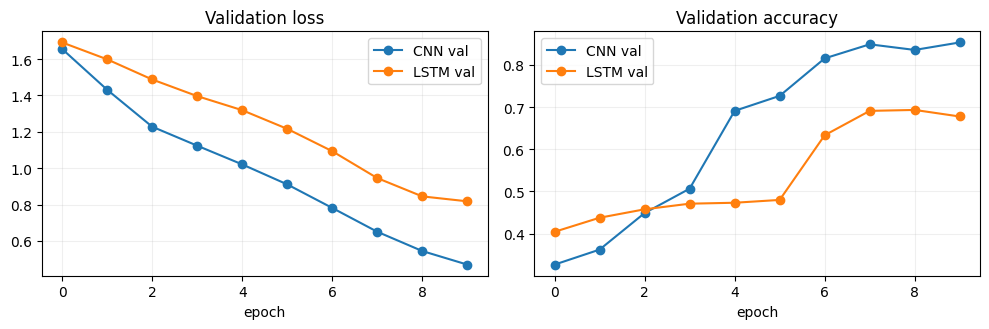

,model,parameters,sec/epoch,test_accuracy
0,1D CNN,3526,0.184,0.791
1,LSTM,3510,0.364,0.577


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(cnn_history["val_loss"], marker="o", label="CNN val")
axes[0].plot(lstm_history["val_loss"], marker="o", label="LSTM val")
axes[0].set_title("Validation loss")
axes[1].plot(cnn_history["val_acc"], marker="o", label="CNN val")
axes[1].plot(lstm_history["val_acc"], marker="o", label="LSTM val")
axes[1].set_title("Validation accuracy")
for ax in axes: ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

comparison = pd.DataFrame([
    {"model": "1D CNN", "parameters": sum(p.numel() for p in cnn.parameters()), "sec/epoch": np.mean(cnn_history["seconds"]), "test_accuracy": cnn_test_acc},
    {"model": "LSTM", "parameters": sum(p.numel() for p in lstm.parameters()), "sec/epoch": np.mean(lstm_history["seconds"]), "test_accuracy": lstm_test_acc},
])
display(comparison.round(3))


## 활동별 예측 결과 확인

전체 accuracy 외에 각 활동에서 맞힌 비율을 보면 서로 비슷한 정적 활동이나 동적 활동을 구분하는 데 어려움이 있는지 알 수 있습니다.

In [19]:
def collect_predictions(model, loader):
    model.eval(); true_values, predictions = [], []
    with torch.no_grad():
        for xb, yb in loader:
            predictions.extend(model(xb.to(DEVICE)).argmax(1).cpu().tolist())
            true_values.extend(yb.tolist())
    return np.array(true_values), np.array(predictions)

_, _, shared_test_loader = make_loaders(SEED)
cnn_true, cnn_pred = collect_predictions(cnn, shared_test_loader)
lstm_true, lstm_pred = collect_predictions(lstm, shared_test_loader)
per_class = []
for class_id, name in enumerate(CLASS_NAMES):
    mask = cnn_true == class_id
    per_class.append({"activity": name, "CNN": (cnn_pred[mask] == class_id).mean(), "LSTM": (lstm_pred[mask] == class_id).mean()})
display(pd.DataFrame(per_class).round(3))


,activity,CNN,LSTM
0,WALKING,0.901,0.750
1,WALKING_UPSTAIRS,0.382,0.222
2,WALKING_DOWNSTAIRS,0.914,0.102
3,SITTING,0.720,0.720
4,STANDING,0.870,0.605
5,LAYING,0.939,0.939


## 틀린 window 하나 살펴보기

예측 실패를 실제 signal로 돌아가 확인하면 window 경계, 센서 noise, 유사 활동 문제를 구분하는 단서가 됩니다.

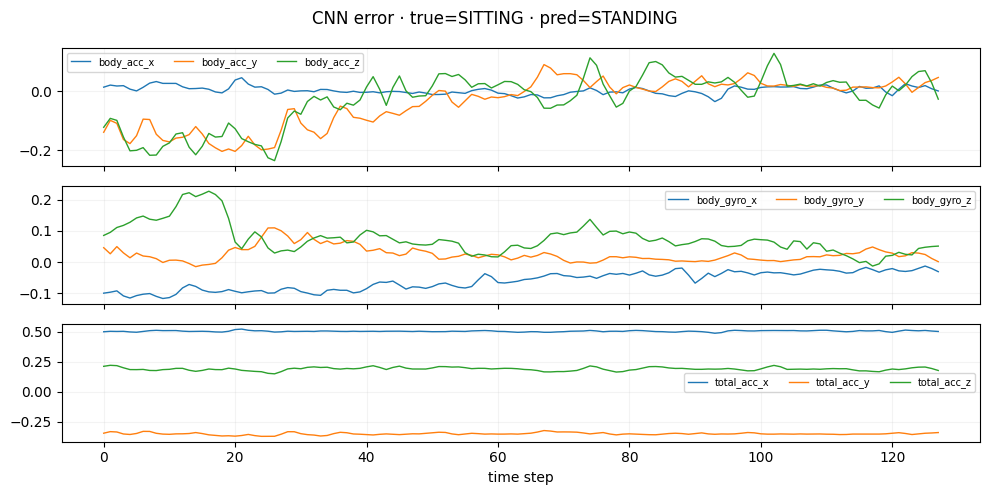

In [20]:
wrong = np.where(cnn_pred != cnn_true)[0]
if len(wrong):
    index = wrong[0]
    sample = X_test[index]
    fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
    for group, ax in enumerate(axes):
        for axis in range(3):
            channel = group * 3 + axis
            ax.plot(sample[channel], label=SIGNAL_NAMES[channel], linewidth=1)
        ax.legend(ncol=3, fontsize=7); ax.grid(alpha=.15)
    axes[-1].set_xlabel("time step")
    fig.suptitle(f"CNN error · true={CLASS_NAMES[cnn_true[index]]} · pred={CLASS_NAMES[cnn_pred[index]]}")
    plt.tight_layout(); plt.show()


**공정 비교 해석**

- 관찰값: 이번 seed·subset·epoch에서 나온 loss/accuracy/시간입니다.
- 구조적 차이: CNN은 지역 패턴과 병렬 계산, LSTM은 순서와 누적 상태가 강점입니다.
- 짧은 수업 결과 하나로 어느 모델이 항상 우수하다고 일반화하지 않습니다.

## 13. 학습자 변경 과제: LSTM hidden size

`LSTM_HIDDEN`을 12 또는 48로 바꾸고 LSTM 정의·학습 셀을 다시 실행하세요.

예상할 변화:

1. hidden size가 커지면 파라미터 수와 epoch 시간이 늘어납니다.
2. train 표현력은 커지지만 validation 개선은 보장되지 않습니다.
3. 같은 데이터 split을 유지해야 비교 의미가 보존됩니다.

In [21]:
print("현재 LSTM hidden:", LSTM_HIDDEN)
print("현재 LSTM parameters:", sum(p.numel() for p in lstm.parameters()))
print("관찰 기록: hidden=___에서 시간은 ___, validation은 ___했다.")


현재 LSTM hidden: 24
현재 LSTM parameters: 3510
관찰 기록: hidden=___에서 시간은 ___, validation은 ___했다.


## 현업 적용 질문·요약

- 실제 센서의 sampling rate가 달라지면 128시점 window의 의미는 어떻게 달라질까요?
- 고장 직전의 짧은 spike가 중요하면 CNN과 LSTM 중 어디서 시작하겠습니까?
- 장기간 상태 누적이 중요하지만 지연시간 제약이 크다면 무엇을 추가 확인해야 할까요?

**핵심:** 같은 tensor라도 Conv1d는 지역 패턴, LSTM은 누적 상태라는 다른 관점으로 읽습니다. 공정 비교는 split·전처리·학습 조건을 먼저 고정해야 합니다.